## 밴드 노이즈 필터링
- 위치: G:\youngweol\data_analysis\2_refactoring

In [162]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates
from pathlib import Path

# Jupyter에서 플롯을 인라인으로 표시
%matplotlib inline

import time


# ============================================================================
# 한글 폰트 설정
# ============================================================================
plt.rcParams['font.family'] = 'DejaVu Sans'
try:
    # Windows 환경에서 한글 폰트 설정
    import platform
    if platform.system() == 'Windows':
        plt.rcParams['font.family'] = 'Malgun Gothic'
    else:
        # Mac/Linux 환경
        plt.rcParams['font.family'] = 'AppleGothic'
except:
    # 폰트 설정 실패시 경고 무시
    import warnings
    warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')
    
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [23]:
class BandNoiseRemoverV02Fixed:
    """Fixed performance-optimized Band Noise Detection"""

    def __init__(self, signal, time=None):
        self.original_signal = signal.copy()
        self.signal = signal.copy()
        self.time = time if time is not None else np.arange(len(signal))

    def detect_band_noise_v02(self, signal, max_band_width, jump_threshold, return_tolerance):
        """
        Fixed optimized band noise detection
        Now produces identical results to v01 while being faster
        """
        noise_regions = []
        detected_info = {
            'total_jumps': 0,
            'valid_bands': 0,
            'rejected_bands': 0,
            'details': []
        }

        # OPTIMIZATION 1: Vectorized difference calculation
        diff = np.diff(signal)
        abs_diff = np.abs(diff)

        # OPTIMIZATION 2: Vectorized jump detection
        jump_indices = np.where(abs_diff >= jump_threshold)[0]

        if len(jump_indices) == 0:
            return noise_regions, detected_info

        # Process detected jumps, but track which ones we've already processed
        processed_until = -1

        for idx_pos, i in enumerate(jump_indices):
            # Skip if already processed as part of previous band
            if i <= processed_until:
                continue

            baseline = signal[i]
            jump = diff[i]
            detected_info['total_jumps'] += 1
            jumped_value = signal[i + 1]

            # OPTIMIZATION 3: Vectorized band extent calculation
            band_start = i + 1
            remaining_signal = signal[band_start:]

            # Find where signal leaves the jumped value
            in_band = np.abs(remaining_signal - jumped_value) <= return_tolerance

            if np.any(~in_band):
                band_end = band_start + np.argmax(~in_band)
            else:
                band_end = len(signal)

            band_width = band_end - band_start

            # OPTIMIZATION 4: Validation
            if 1 <= band_width <= max_band_width:
                if band_end < len(signal):
                    return_value = signal[band_end]
                    recovery_distance = abs(return_value - baseline)

                    if recovery_distance <= return_tolerance:
                        noise_regions.append((band_start, band_end))
                        detected_info['valid_bands'] += 1
                        detected_info['details'].append({
                            'idx': band_start,
                            'width': band_width,
                            'jump': jump,
                            'status': 'VALID'
                        })
                        processed_until = band_end - 1
                        continue
                else:
                    noise_regions.append((band_start, band_end))
                    detected_info['valid_bands'] += 1
                    detected_info['details'].append({
                        'idx': band_start,
                        'width': band_width,
                        'jump': jump,
                        'status': 'VALID (EOSignal)'
                    })
                    processed_until = band_end - 1

            else:
                detected_info['rejected_bands'] += 1
                detected_info['details'].append({
                    'idx': band_start,
                    'width': band_width,
                    'jump': jump,
                    'status': f'REJECTED'
                })

        return noise_regions, detected_info

    def remove_band_noise(self, signal, noise_regions, method='interpolate'):
        """Optimized noise removal"""
        cleaned_signal = signal.copy()

        for start, end in noise_regions:
            if method == 'interpolate':
                if start > 0 and end < len(signal):
                    pre_value = signal[start - 1]
                    post_value = signal[end]
                    cleaned_signal[start:end] = np.linspace(pre_value, post_value, end - start)
                elif start > 0:
                    cleaned_signal[start:end] = signal[start - 1]
                else:
                    cleaned_signal[start:end] = signal[end]

        return cleaned_signal

In [24]:
# Load signal
signal = "data/output_v1/20250325_155410_crop.feather"

In [157]:
# ============================================================================
# 데이터 로드 함수 (HDF5 및 Feather 지원)
# ============================================================================

def load_data_from_file(file_path):
    """
    Feather, HDF5, CSV 파일을 자동으로 인식하여 로드합니다.
    
    Parameters:
    -----------
    file_path : str
        로드할 파일 경로 (.feather, .h5, .hdf5, .csv)
    
    Returns:
    --------
    df : DataFrame
        로드된 데이터프레임
    """
    file_path = str(file_path).lower()
    
    if file_path.endswith('.feather'):
        print(f"📁 Loading Feather file: {file_path}")
        df = pd.read_feather(file_path)
        print(f"✅ Feather 파일 로드 완료")
        print(f"   Shape: {df.shape}")
        print(f"   Columns: {df.columns.tolist()}")
        return df
    
    elif file_path.endswith(('.h5', '.hdf5')):
        print(f"📁 Loading HDF5 file: {file_path}")
        df = pd.read_hdf(file_path)
        print(f"✅ HDF5 파일 로드 완료")
        print(f"   Shape: {df.shape}")
        print(f"   Columns: {df.columns.tolist()}")
        return df
    
    elif file_path.endswith('.csv'):
        print(f"📁 Loading CSV file: {file_path}")
        df = pd.read_csv(file_path)
        print(f"✅ CSV 파일 로드 완료")
        print(f"   Shape: {df.shape}")
        print(f"   Columns: {df.columns.tolist()}")
        return df
    
    else:
        raise ValueError(f"지원하지 않는 파일 형식입니다: {file_path}")


# ============================================================================
# 신호 로드 및 처리
# ============================================================================

# Feather 파일 로드
#signal_file_path = "data/output_v1/20250324_151145_crop.feather"
signal_file_path = "data/output_v1/20250414_060455_crop.feather"


try:
    df = load_data_from_file(signal_file_path)
    
    # DataFrame에서 신호 추출 (첫 번째 숫자 컬럼 사용)
    # 필요에 따라 특정 컬럼명을 지정할 수 있습니다
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    if numeric_cols:
        signal_col = numeric_cols[0]  # 첫 번째 숫자 컬럼
        signal = df[signal_col].values
        print(f"\n📊 신호 추출 완료")
        print(f"   사용 컬럼: {signal_col}")
        print(f"   신호 길이: {len(signal)}")
        print(f"   신호 범위: [{signal.min():.4f}, {signal.max():.4f}]")
    else:
        raise ValueError("DataFrame에 숫자 컬럼이 없습니다.")
        
except FileNotFoundError:
    print(f"⚠️  파일을 찾을 수 없습니다: {signal_file_path}")
    print("   파일 경로를 확인해주세요.")
    signal = None

📁 Loading Feather file: data/output_v1/20250414_060455_crop.feather
✅ Feather 파일 로드 완료
   Shape: (13618, 25)
   Columns: ['timestamp', 'gt_fuel_consumption', 'embient_temp', 'ammonia_water_line_pressure', 'compressed_air_line_pressure', 'injection_control_valve_opening_rate', 'metal_temp_1st', 'ammonia_supply_flow', 'inlet_nox', 'inlet_o2', 'outlet_nox', 'outlet_nh3', 'outlet_o2', 'scr_outlet_temp', 'nox_tms', 'mw_output', 'ammonia_tank_level', 'exhaust_gas_temperature', 'st_mw_output', 'gt_exhaust', 'scr_inlet_no', 'scr_inlet_no2', 'nh3_control', 'gt_ignition', 'sp_out_elcp']

📊 신호 추출 완료
   사용 컬럼: gt_fuel_consumption
   신호 길이: 13618
   신호 범위: [nan, nan]


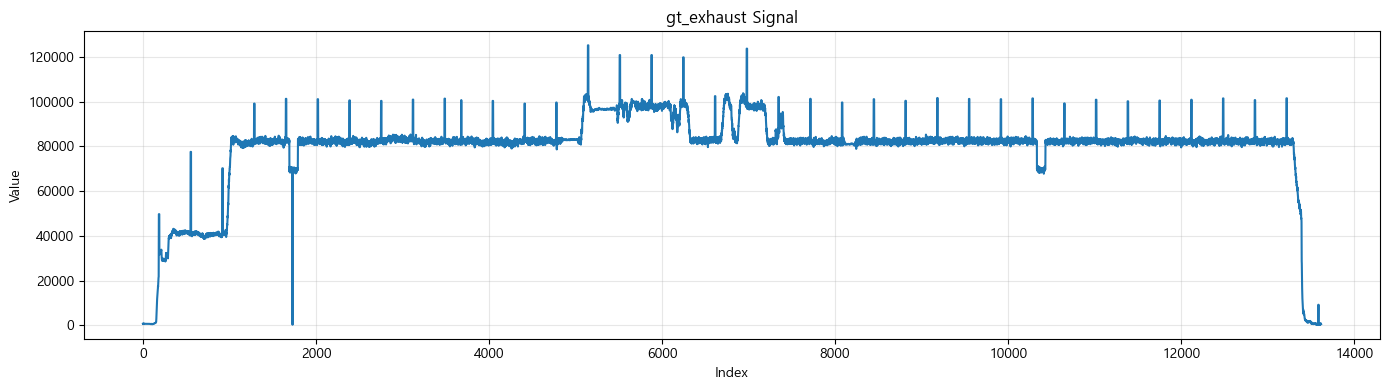


데이터 정보:
gt_exhaust - Min: 312.7093506, Max: 125207.7421875
gt_exhaust - NaN 개수: 0


In [158]:
df['gt_exhaust'].plot(figsize=(14, 4))
plt.title('gt_exhaust Signal')
plt.xlabel('Index')
plt.ylabel('Value')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n데이터 정보:")
print(f"gt_exhaust - Min: {df['gt_exhaust'].min()}, Max: {df['gt_exhaust'].max()}")
print(f"gt_exhaust - NaN 개수: {df['gt_exhaust'].isna().sum()}")
#print(f"gt_exhaust - 처음 10개 값:\n{df['gt_exhaust'].head(10)}")

In [159]:
signal = df['gt_exhaust'].copy()

In [160]:
params = {
    'max_band_width': 30,  # 이 값보다 더 크면 노이즈가 아니라 신호
    'jump_threshold': 5000,  # 현재 값에서 이 값보다 더 튀어야 노이즈 타겟
    'return_tolerance': 8000  # 출발점에서 band내 현재값이 이 값보다 커야 band가 지속되는것으로 봄
}

# Performance test - V02 FIXED
detector_v02 = BandNoiseRemoverV02Fixed(signal)
start_time = time.time()
regions_v02, info_v02 = detector_v02.detect_band_noise_v02(signal, **params)
time_v02 = time.time() - start_time

cleaned_v02 = detector_v02.remove_band_noise(signal, regions_v02)
print(f"Detection time: {time_v02*1000:.3f} ms")
print(f"Detected {info_v02['valid_bands']} valid bands, {info_v02['rejected_bands']} rejected")

Detection time: 6.864 ms
Detected 38 valid bands, 5 rejected


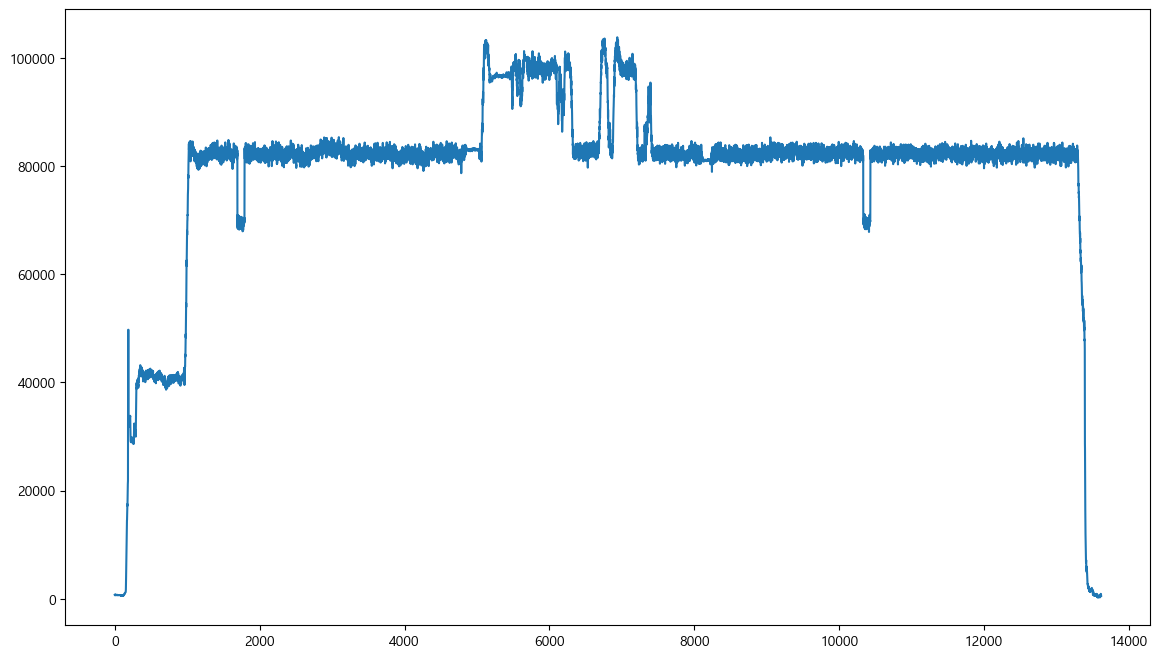

In [161]:
plt.figure(figsize=(14,8))
plt.plot(cleaned_v02)
#plt.xlim(0,500)
plt.show()
plt.close()

### working한다는 것이 확인되었으니 이제 모든 데이터에 대해 적용

In [145]:
def remove_noise(signal):
    detector_v02 = BandNoiseRemoverV02Fixed(signal)
    start_time = time.time()
    regions_v02, info_v02 = detector_v02.detect_band_noise_v02(signal, **params)
    time_v02 = time.time() - start_time    
    cleaned_v02 = detector_v02.remove_band_noise(signal, regions_v02)
    return cleaned_v02, time_v02

def plot_signal(signal):
    signal.plot(figsize=(14, 4))
    plt.title('gt_exhaust Signal')
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()    
    plt.close()

Loaded: 20250415_041345_crop.feather, Tak Time:0.00255584716796875


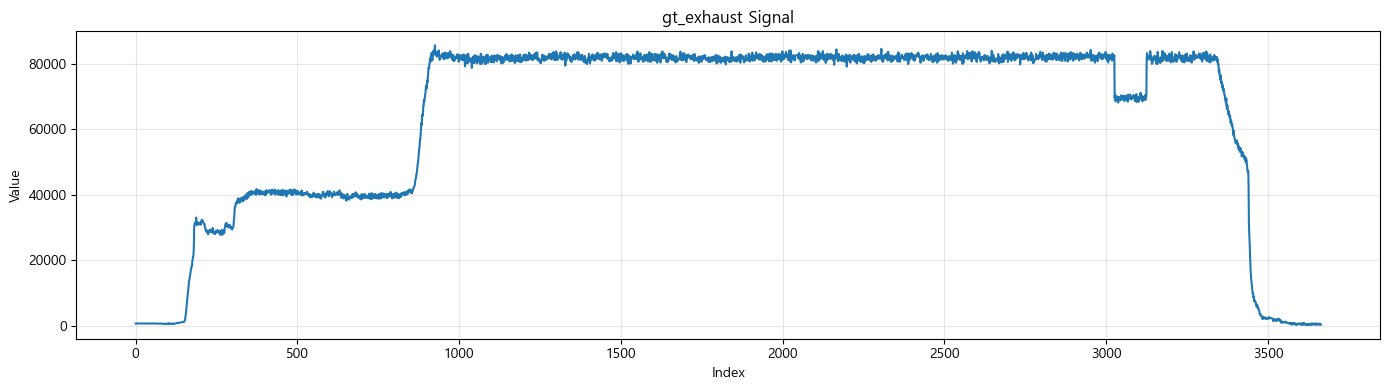

Loaded: 20250416_140500_crop.feather, Tak Time:0.0029993057250976562


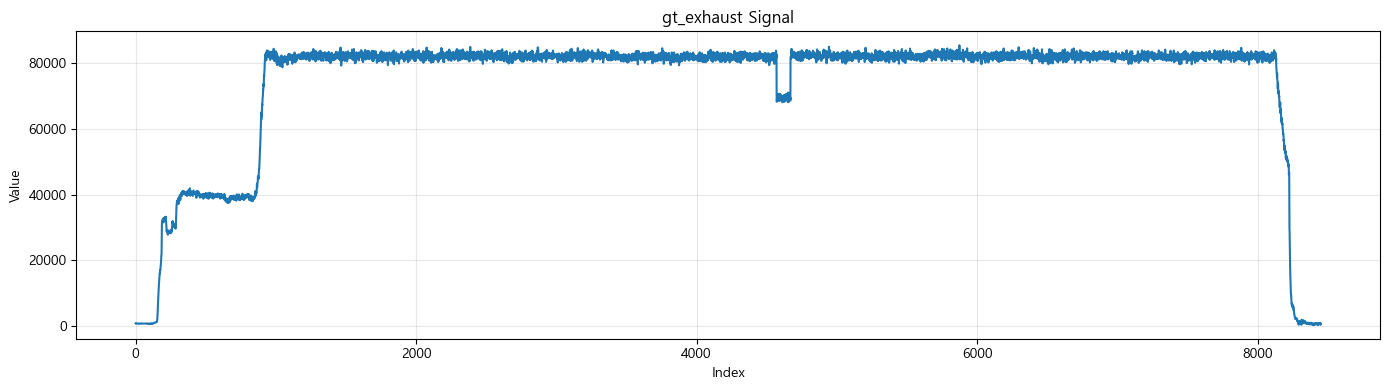

Loaded: 20250417_050415_crop.feather, Tak Time:0.0029990673065185547


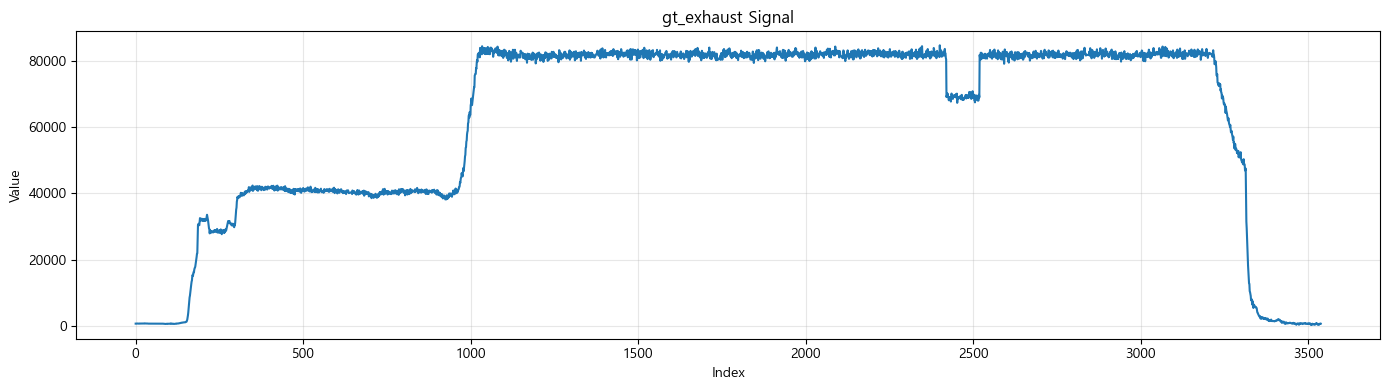

Loaded: 20250417_140505_crop.feather, Tak Time:0.002999544143676758


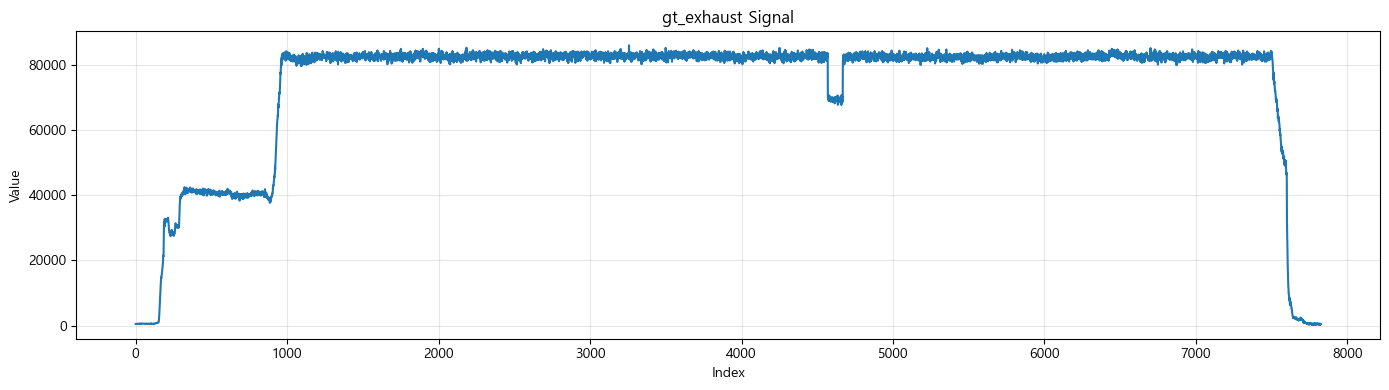

Loaded: 20250418_150320_crop.feather, Tak Time:0.005999565124511719


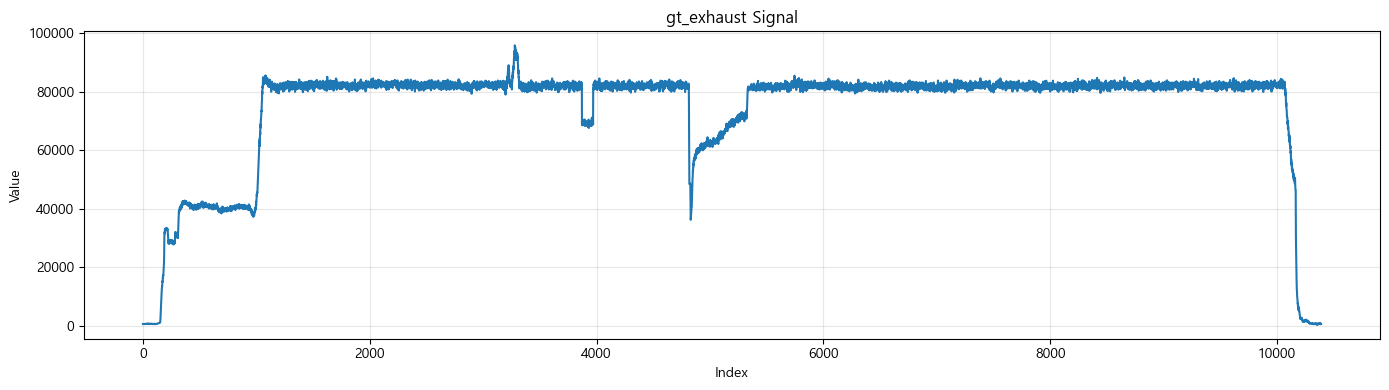

Loaded: 20250419_143430_crop.feather, Tak Time:0.0039997100830078125


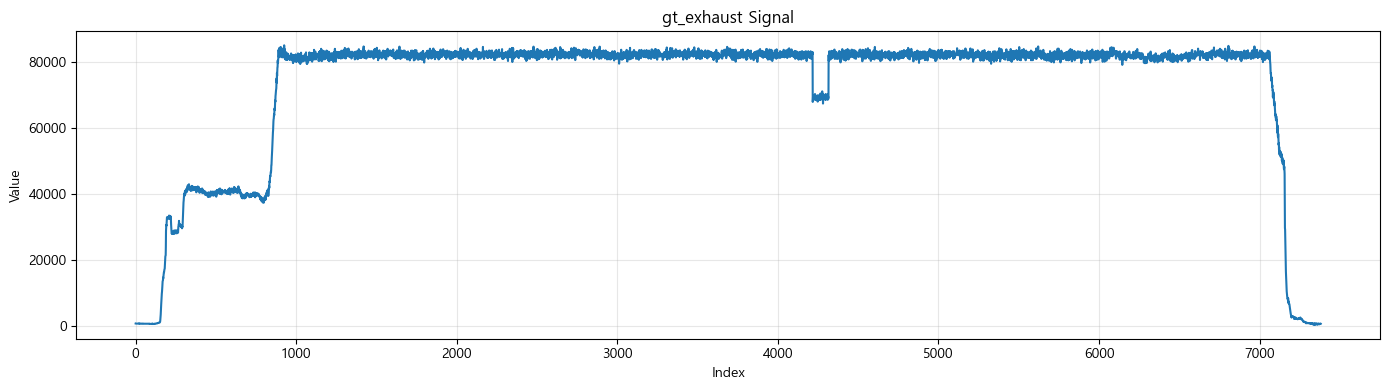

Loaded: 20250420_151510_crop.feather, Tak Time:0.0029990673065185547


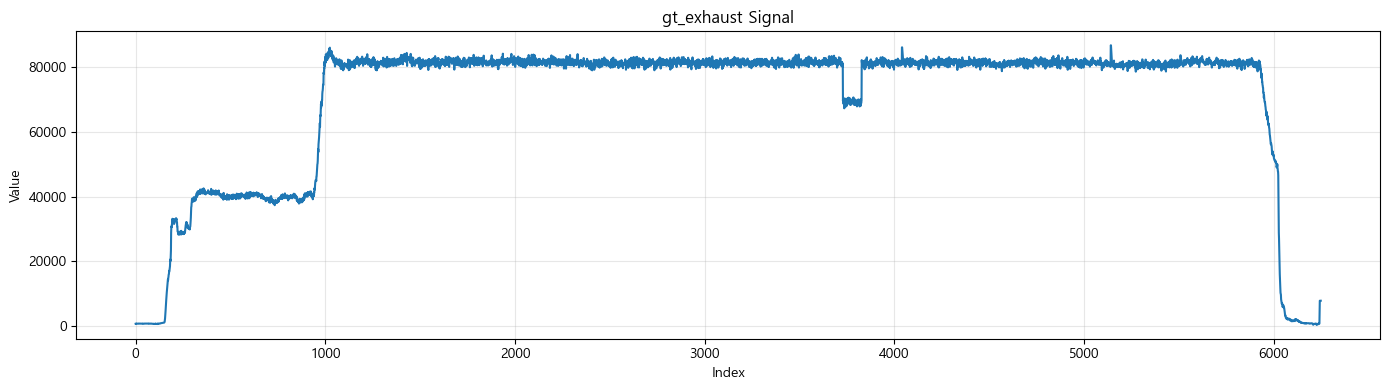

Loaded: 20250421_040400_crop.feather, Tak Time:0.0060007572174072266


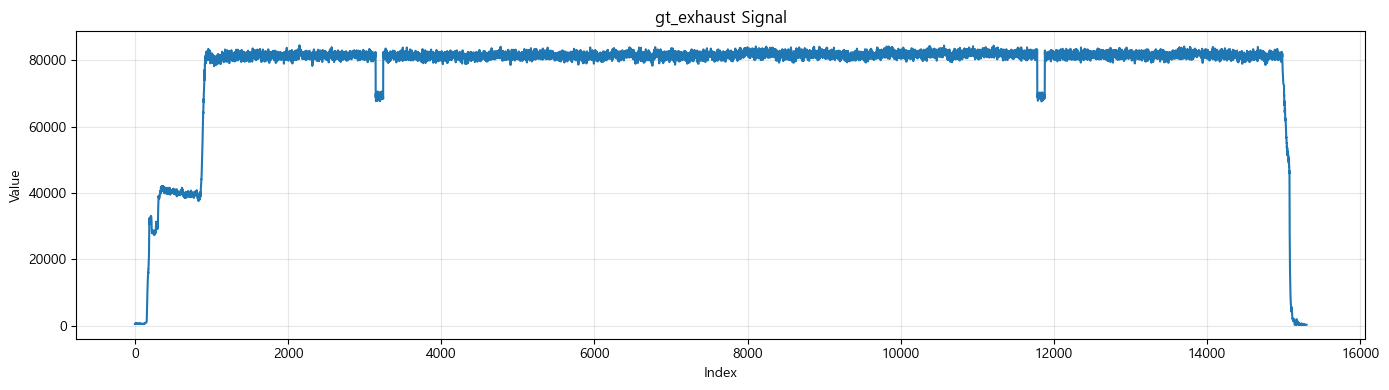

Loaded: 20250422_063500_crop.feather, Tak Time:0.00599980354309082


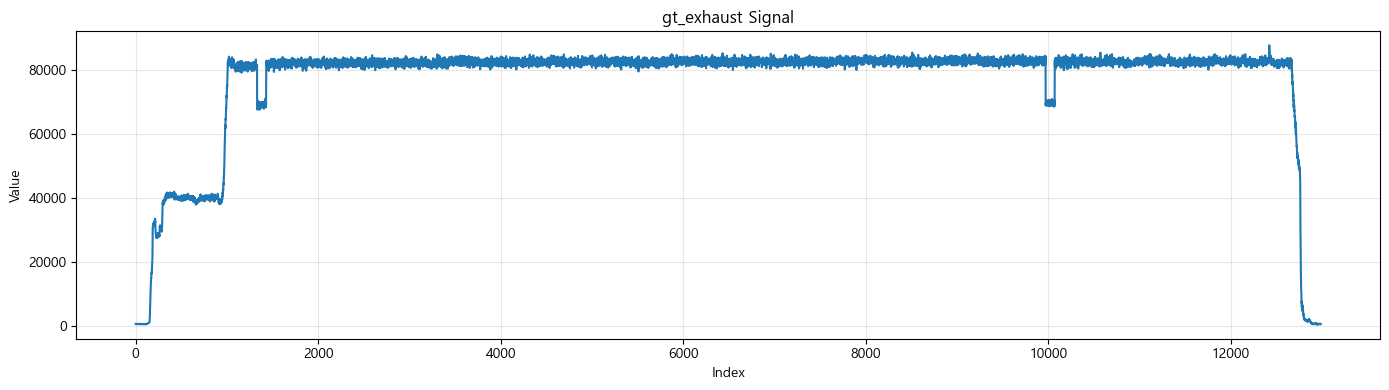

Loaded: 20250504_165645_crop.feather, Tak Time:0.003998994827270508


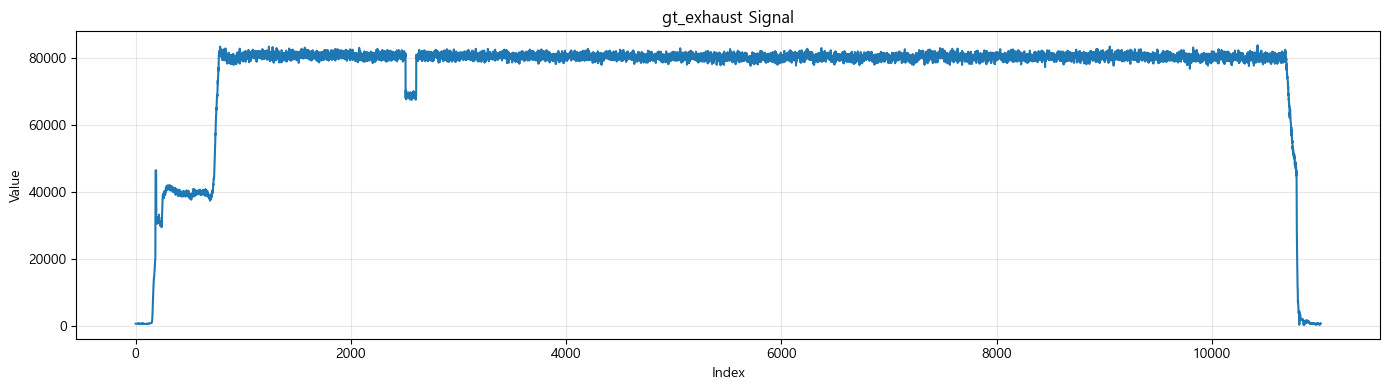

Loaded: 20250505_113500_crop.feather, Tak Time:0.01399993896484375


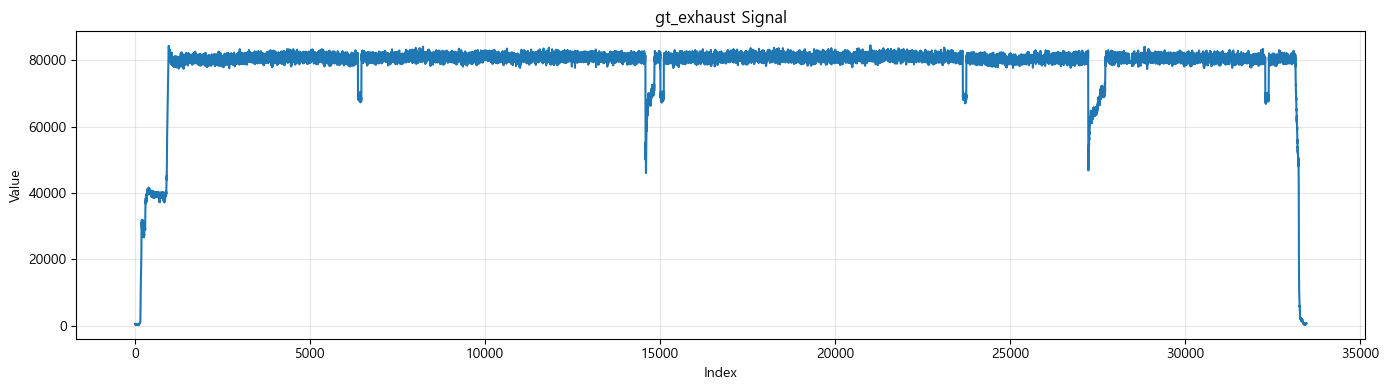

Loaded: 20250507_133505_crop.feather, Tak Time:0.0059986114501953125


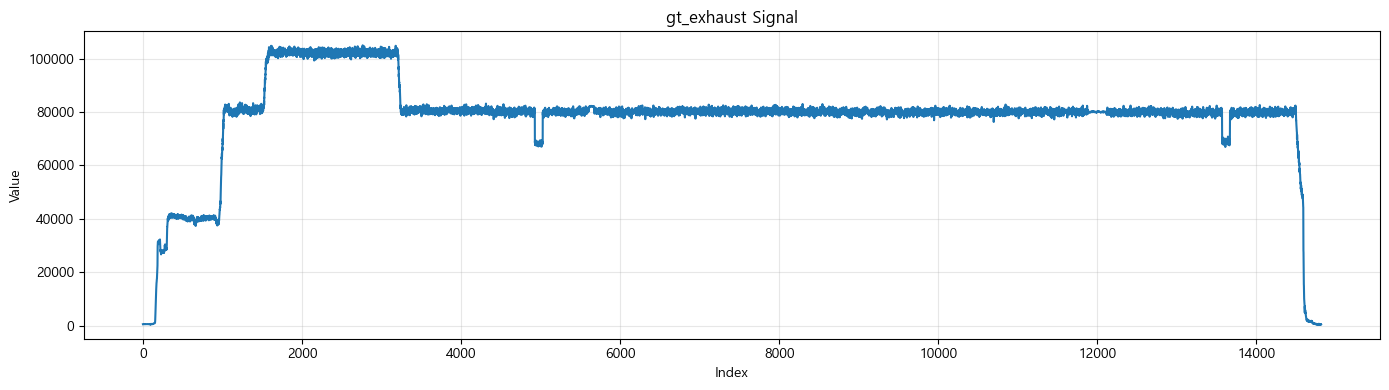

Loaded: 20250508_140340_crop.feather, Tak Time:0.003999471664428711


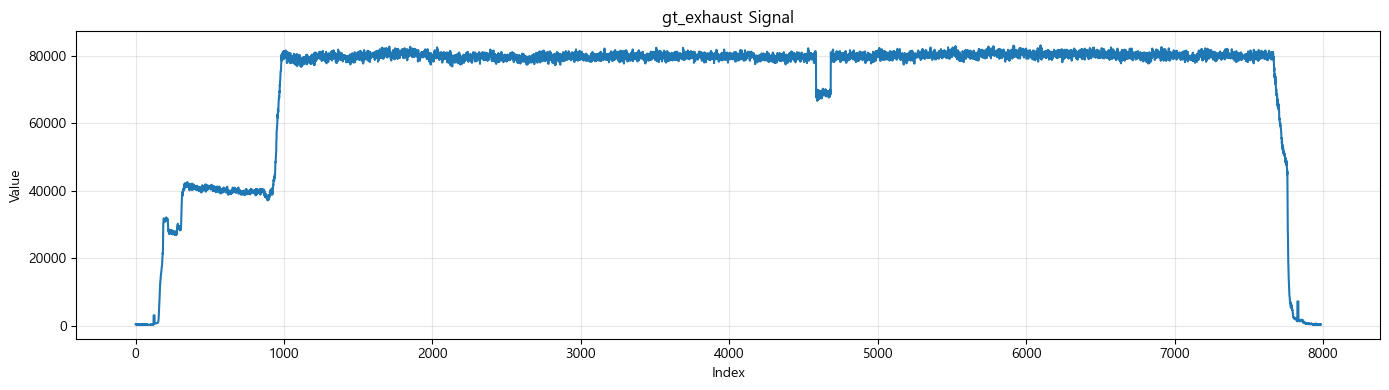

Loaded: 20250509_051505_crop.feather, Tak Time:0.003000974655151367


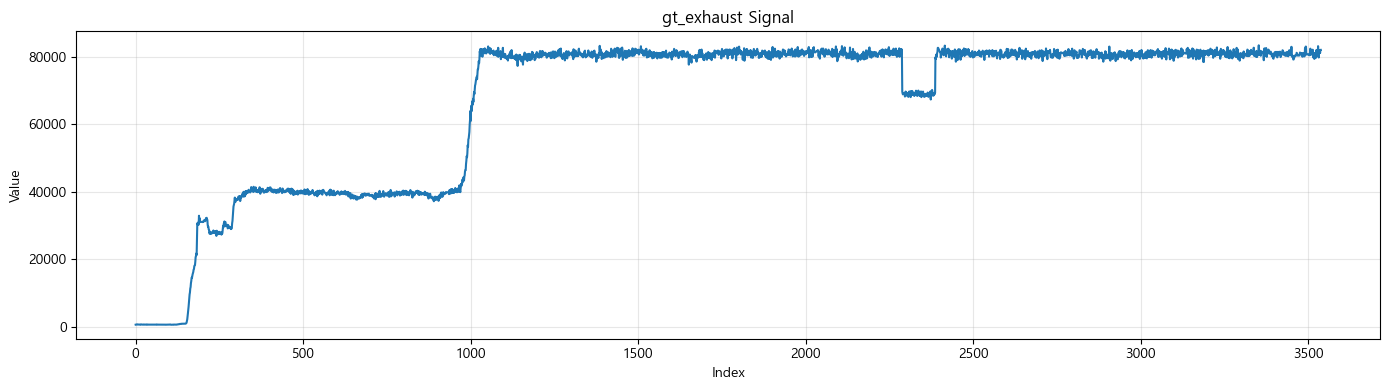

Loaded: 20250510_103400_crop.feather, Tak Time:0.007999420166015625


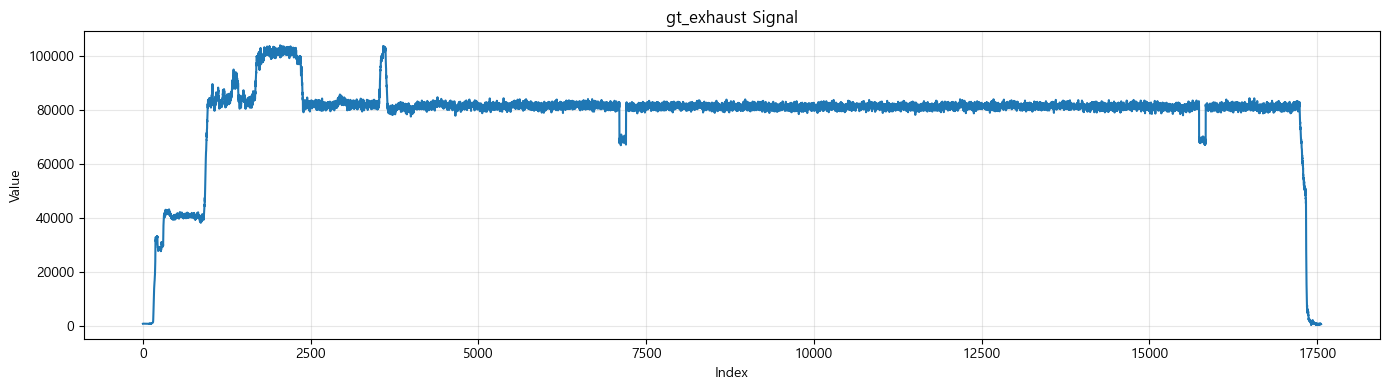

Loaded: 20250511_150500_crop.feather, Tak Time:0.012998819351196289


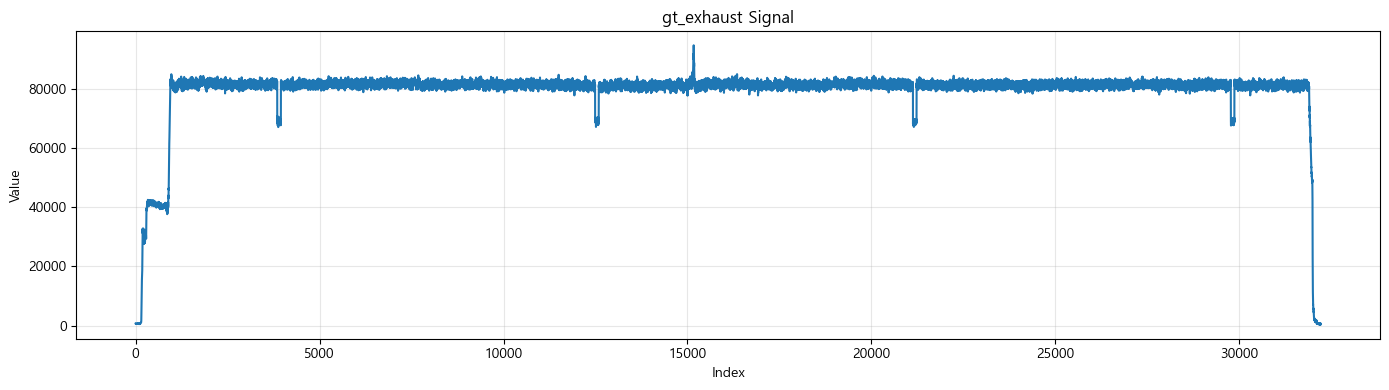

Loaded: 20250513_140310_crop.feather, Tak Time:0.006001472473144531


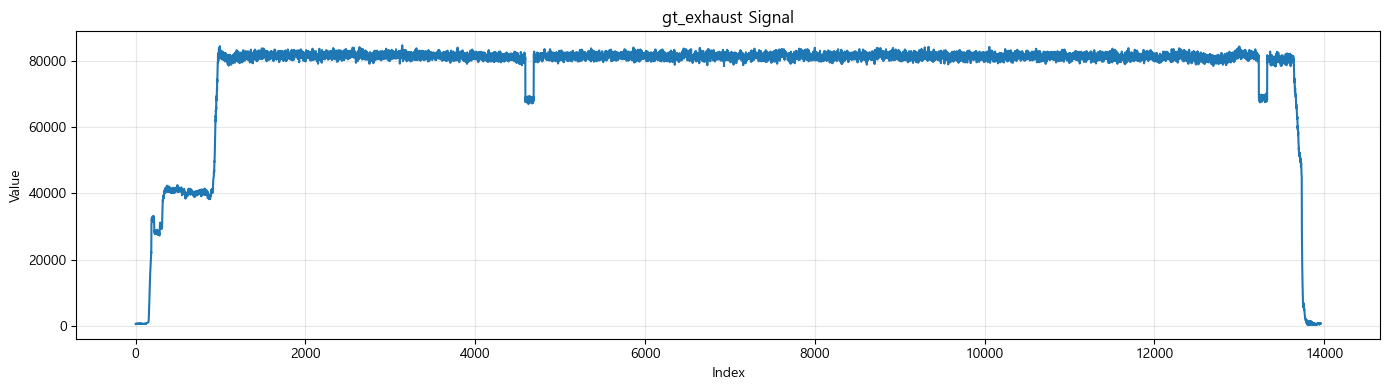

Loaded: 20250514_113835_crop.feather, Tak Time:0.008000373840332031


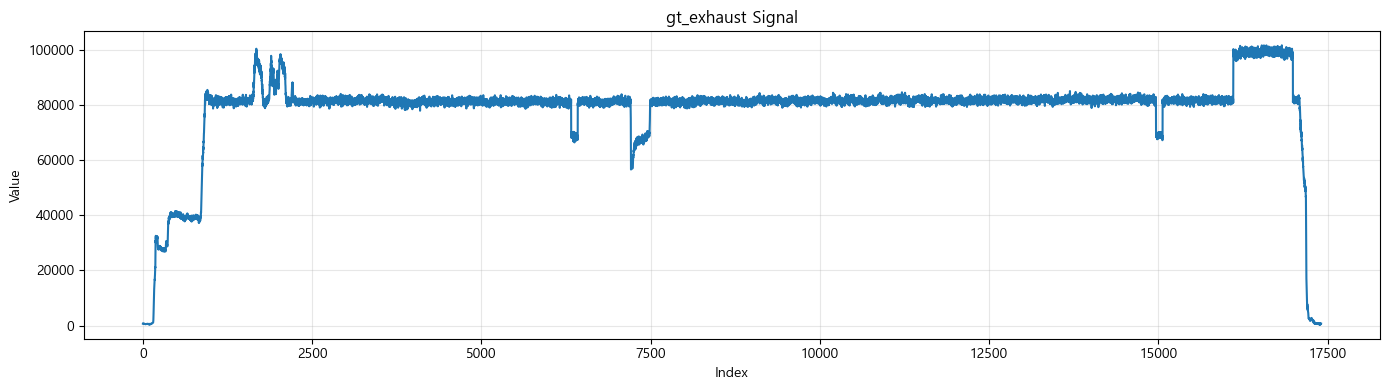

Loaded: 20250515_141500_crop.feather, Tak Time:0.0029997825622558594


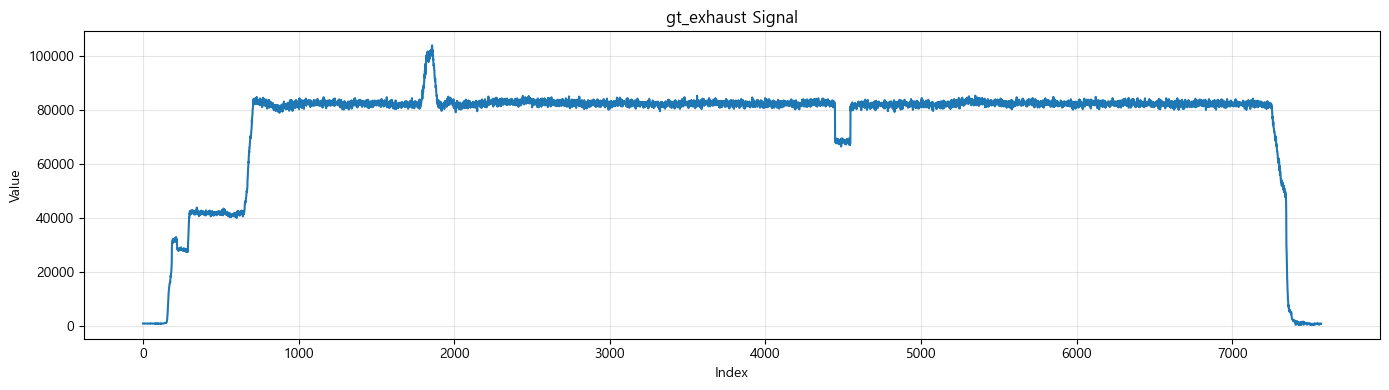

Loaded: 20250516_053415_crop.feather, Tak Time:0.007999420166015625


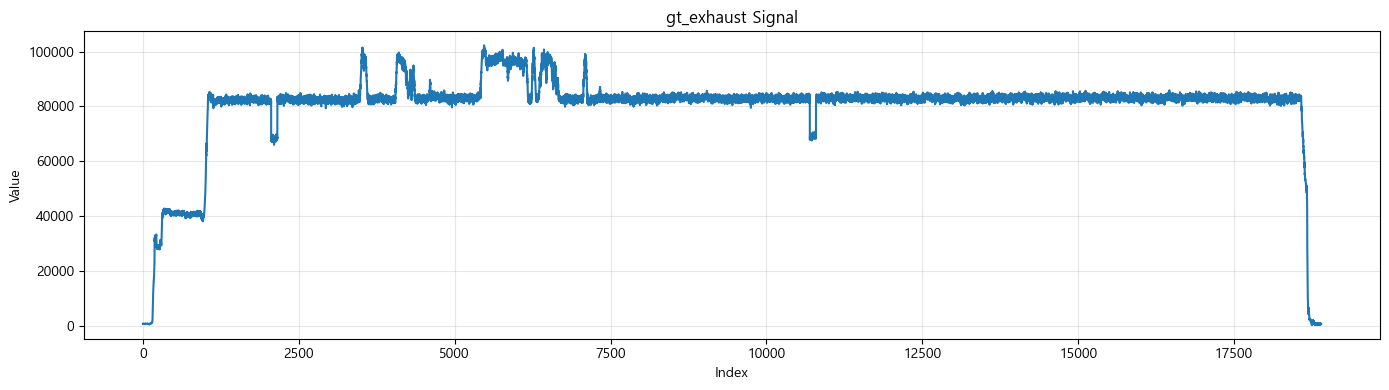

Loaded: 20250517_150500_crop.feather, Tak Time:0.004998683929443359


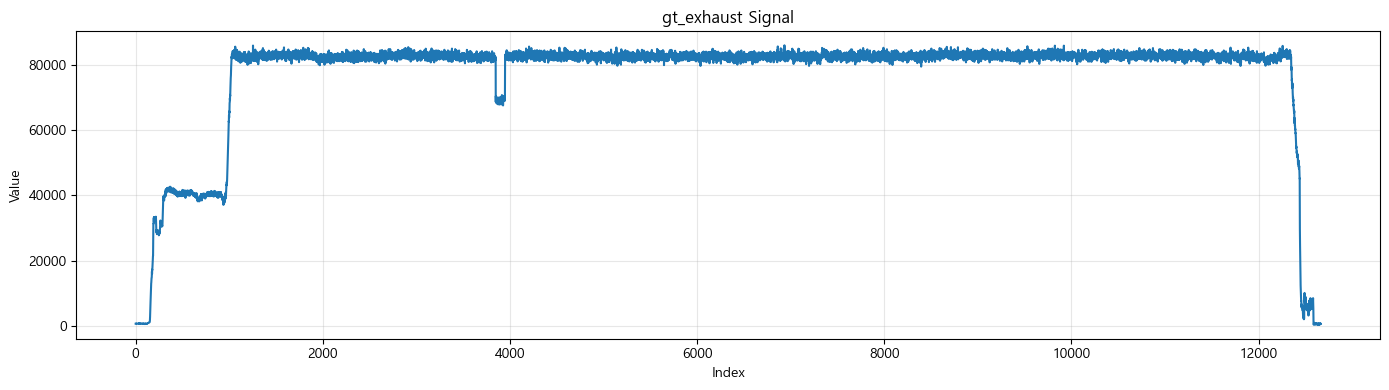

Loaded: 20250518_160310_crop.feather, Tak Time:0.01599907875061035


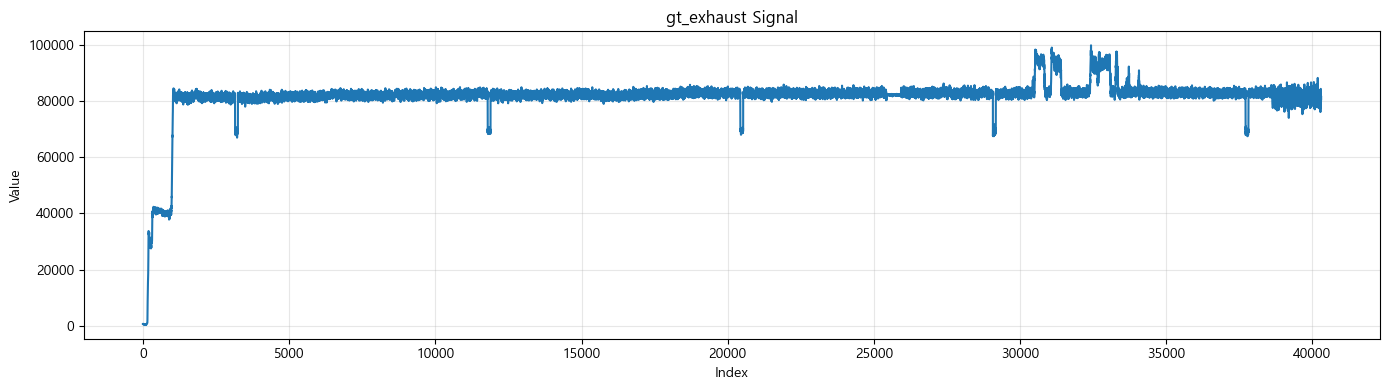

Loaded: 20250525_141515_crop.feather, Tak Time:0.010998964309692383


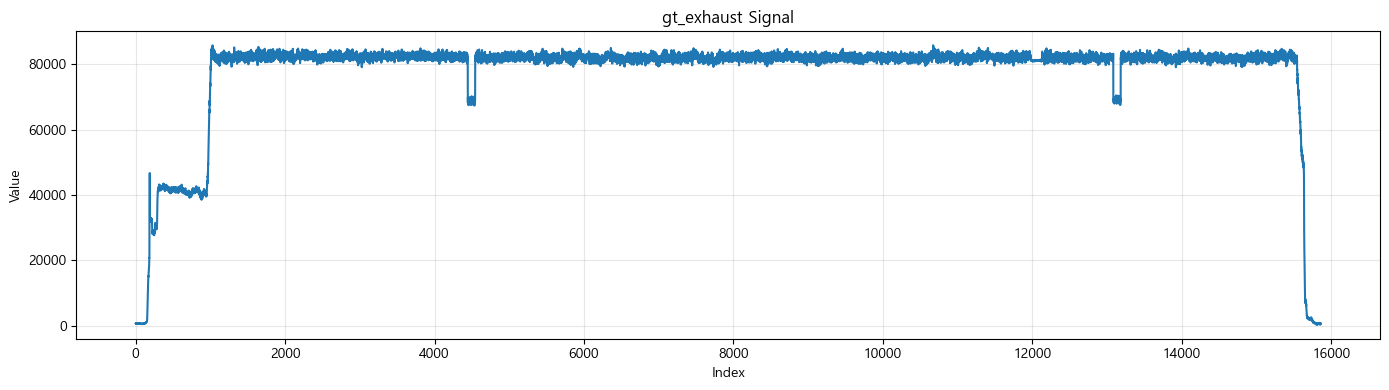

Loaded: 20250526_143505_crop.feather, Tak Time:0.0039997100830078125


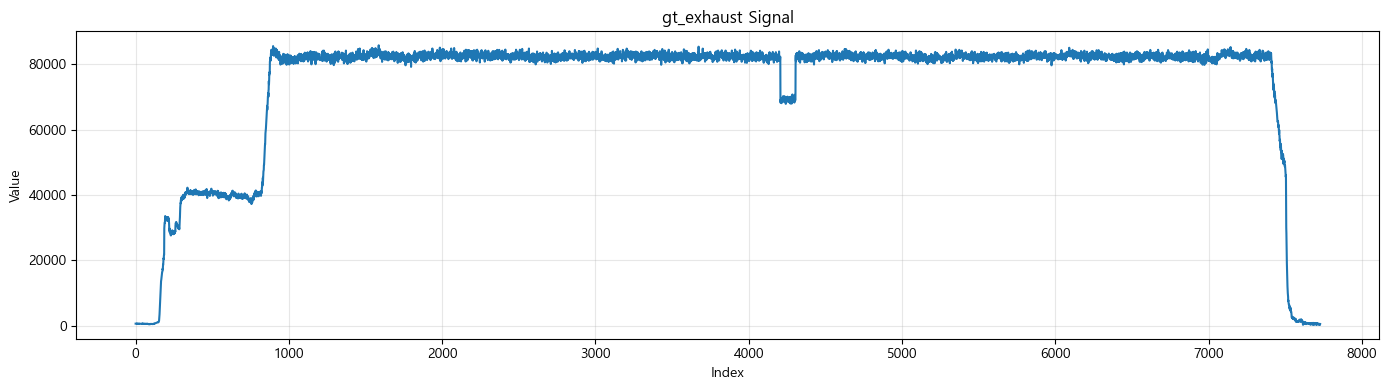

Loaded: 20250527_040515_crop.feather, Tak Time:0.002000570297241211


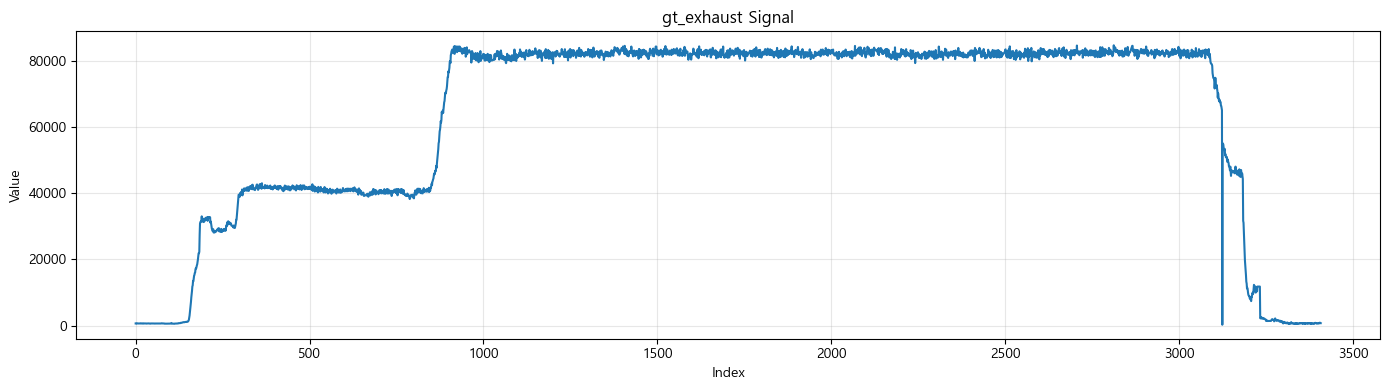

Loaded: 20250527_130510_crop.feather, Tak Time:0.010999441146850586


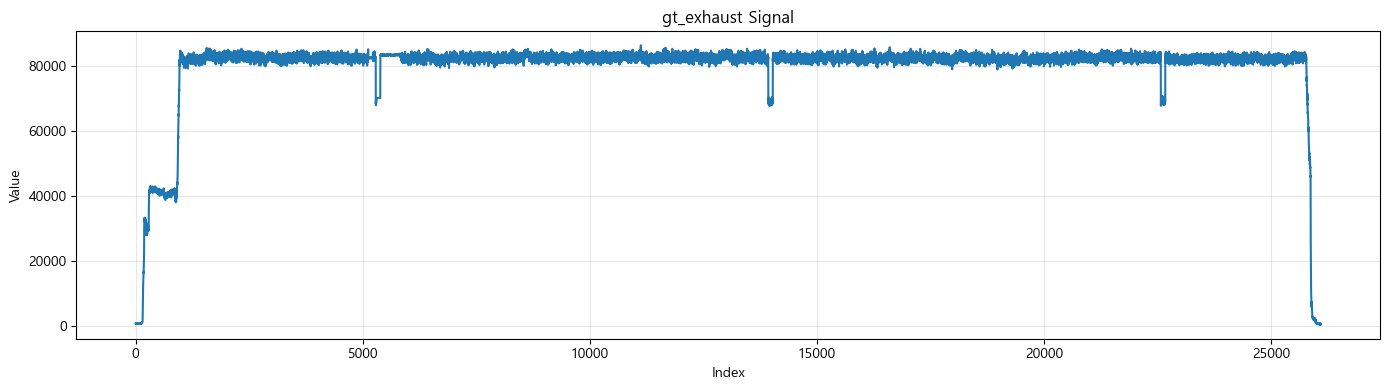

Loaded: 20250529_124350_crop.feather, Tak Time:0.003999471664428711


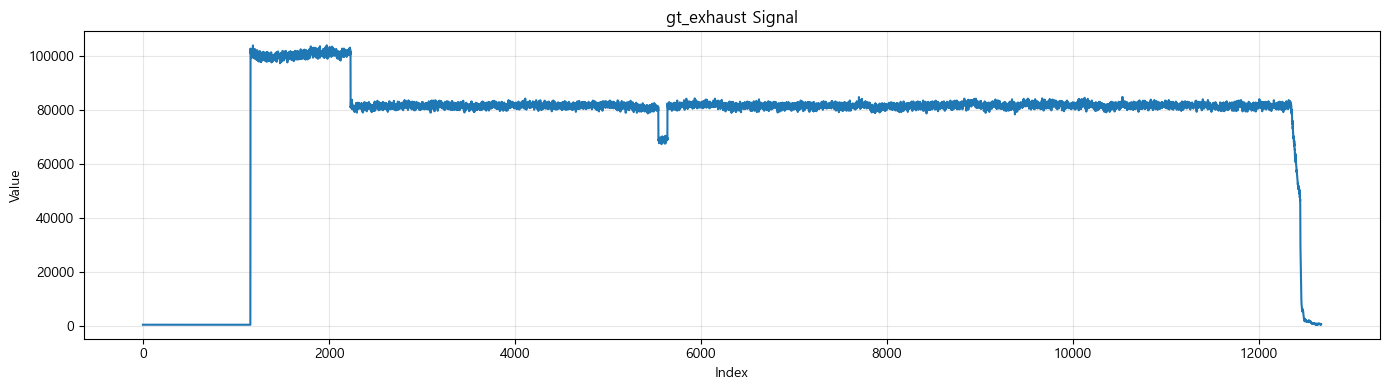

In [155]:
from pathlib import Path
import os
import pdb

# 특정 폴더의 모든 .feather 파일 찾기
folder_path = Path('data/output_v3')
output_path = os.path.join('data/filtered_v3')
feather_files = list(folder_path.glob('*.feather'))

# 각 파일 읽기
feathers = []
for file in feather_files:
    df = pd.read_feather(file)
    
    signal = df['gt_exhaust'].copy()
    cleaned, time_v02 = remove_noise(signal)
    print(f"Loaded: {file.name}, Tak Time:{time_v02}")
    df['gt_exhaust'] = cleaned
    plot_signal(df['gt_exhaust'])
    df.to_feather(os.path.join(output_path, file.name))
    feathers.append(df)